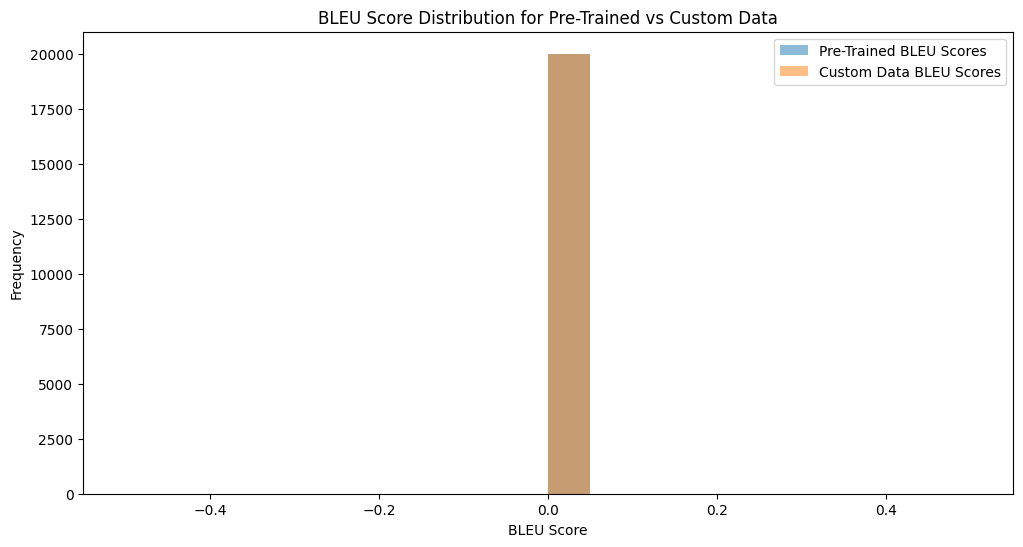

Average BLEU Scores:
Pre-Trained BLEU Scores    0.0
Custom Data BLEU Scores    0.0
dtype: float64


In [ ]:
import pandas as pd
import nltk
from nltk.translate.bleu_score import sentence_bleu
import matplotlib.pyplot as plt
pre_trained_df = pd.read_csv('/content/sample_data/LLM_Pre_Trained.csv')
custom_data_df = pd.read_csv('/content/sample_data/LLM_Custom_Data.csv')
pre_trained_sentences = pre_trained_df['function source'].tolist()
custom_data_sentences = custom_data_df['function source'].tolist()
pre_trained_references = pre_trained_df['vulnerabilities'].tolist()
custom_data_references = custom_data_df['vulnerabilities'].tolist()

pre_trained_sentences = pre_trained_sentences[:20000]
pre_trained_references = pre_trained_references[:20000]

pre_trained_bleu_scores = [
    sentence_bleu([ref.split()], sent.split()) for ref, sent in zip(pre_trained_references, pre_trained_sentences)
]
custom_data_bleu_scores = [
    sentence_bleu([ref.split()], sent.split()) for ref, sent in zip(custom_data_references, custom_data_sentences)
]
bleu_scores_df = pd.DataFrame({
    'Pre-Trained BLEU Scores': pre_trained_bleu_scores,
    'Custom Data BLEU Scores': custom_data_bleu_scores
})

plt.figure(figsize=(12, 6))
plt.hist(bleu_scores_df['Pre-Trained BLEU Scores'], bins=20, alpha=0.5, label='Pre-Trained BLEU Scores')
plt.hist(bleu_scores_df['Custom Data BLEU Scores'], bins=20, alpha=0.5, label='Custom Data BLEU Scores')
plt.xlabel('BLEU Score')
plt.ylabel('Frequency')
plt.title('BLEU Score Distribution for Pre-Trained vs Custom Data')
plt.legend()
plt.show()
avg_bleu_scores = bleu_scores_df.mean()
print("Average BLEU Scores:")
print(avg_bleu_scores)


In [ ]:
!pip install rouge-score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=9127a156792adfbc8b264b1dd09fe0aaa93d0f1cd98c80e1d273e6698e351d59
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge-score


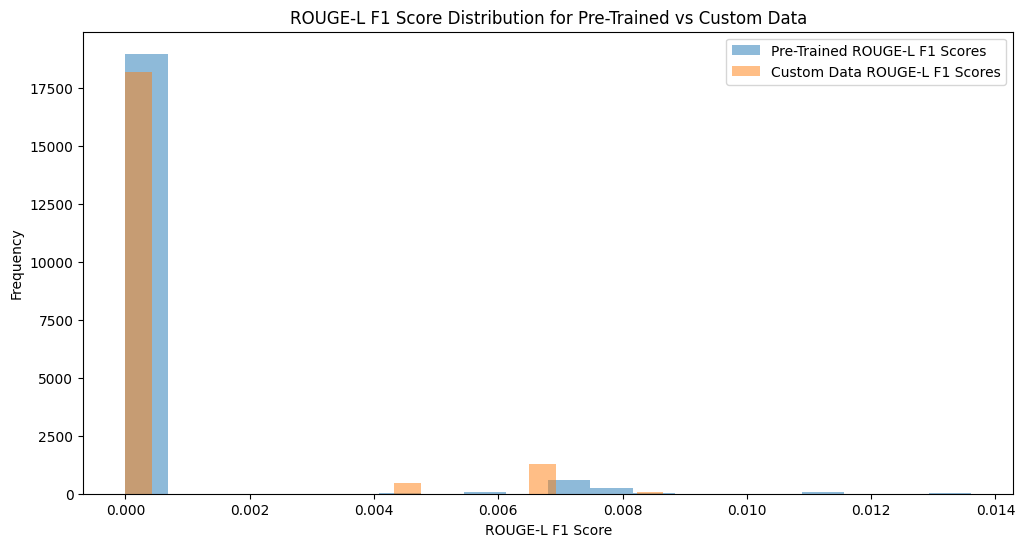

Average ROUGE-L F1 Scores:
Pre-Trained ROUGE-L F1 Scores    0.000403
Custom Data ROUGE-L F1 Scores    0.000570
dtype: float64


In [ ]:
import pandas as pd
import nltk
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

pre_trained_df = pd.read_csv('/content/sample_data/LLM_Pre_Trained.csv')
custom_data_df = pd.read_csv('/content/sample_data/LLM_Custom_Data.csv')

pre_trained_sentences = pre_trained_df['function source'].tolist()
custom_data_sentences = custom_data_df['function source'].tolist()
pre_trained_references = pre_trained_df['vulnerabilities'].tolist()
custom_data_references = custom_data_df['vulnerabilities'].tolist()

pre_trained_sentences = pre_trained_sentences[:20000]
pre_trained_references = pre_trained_references[:20000]

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
pre_trained_rouge_l_f1 = [
    scorer.score(ref, sent)['rougeL'].fmeasure for ref, sent in zip(pre_trained_references, pre_trained_sentences)
]
custom_data_rouge_l_f1 = [
    scorer.score(ref, sent)['rougeL'].fmeasure for ref, sent in zip(custom_data_references, custom_data_sentences)
]
rouge_scores_df = pd.DataFrame({
    'Pre-Trained ROUGE-L F1 Scores': pre_trained_rouge_l_f1,
    'Custom Data ROUGE-L F1 Scores': custom_data_rouge_l_f1
})
plt.figure(figsize=(12, 6))
plt.hist(rouge_scores_df['Pre-Trained ROUGE-L F1 Scores'], bins=20, alpha=0.5, label='Pre-Trained ROUGE-L F1 Scores')
plt.hist(rouge_scores_df['Custom Data ROUGE-L F1 Scores'], bins=20, alpha=0.5, label='Custom Data ROUGE-L F1 Scores')
plt.xlabel('ROUGE-L F1 Score')
plt.ylabel('Frequency')
plt.title('ROUGE-L F1 Score Distribution for Pre-Trained vs Custom Data')
plt.legend()
plt.show()
avg_rouge_scores = rouge_scores_df.mean()
print("Average ROUGE-L F1 Scores:")
print(avg_rouge_scores)


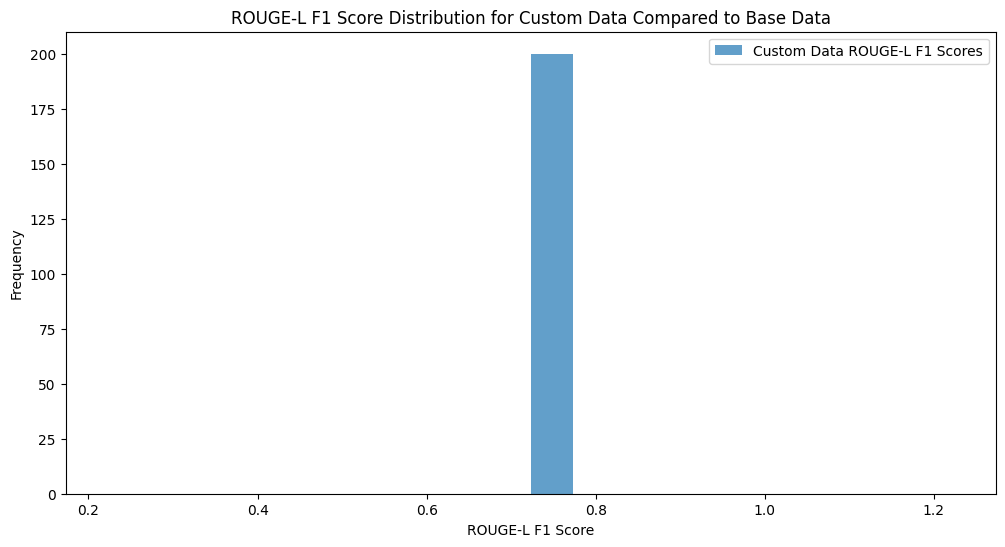

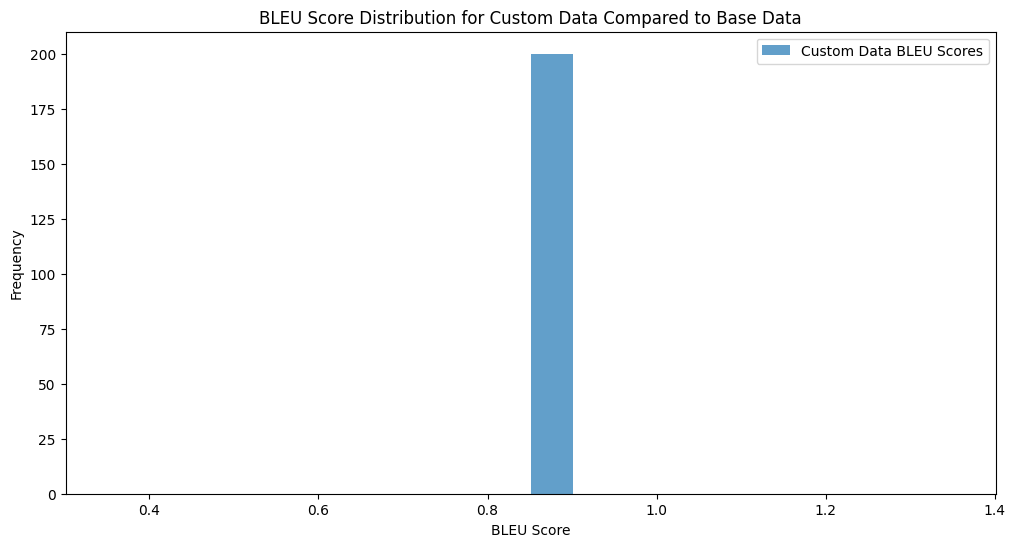

Average ROUGE-L F1 and BLEU Scores:
Custom Data ROUGE-L F1 Scores    0.723
Custom Data BLEU Scores          0.851
dtype: float64


In [13]:
import pandas as pd
import nltk
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt

base_data_df = pd.read_excel('/content/sample_data/LLM_base_data.xlsx')
custom_data_df = pd.read_csv('/content/sample_data/LLM_Custom_Data.csv')

base_sentences = base_data_df['function source'].tolist()
custom_data_sentences = custom_data_df['function source'].tolist()
base_references = base_data_df['vulnerabilities'].tolist()
custom_data_references = custom_data_df['vulnerabilities'].tolist()

base_sentences = base_sentences[:len(custom_data_sentences)]
base_references = base_references[:len(custom_data_references)]

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

rouge_l_f1_scores = [
    scorer.score(ref, sent)['rougeL'].fmeasure for ref, sent in zip(base_references, custom_data_sentences)
]
bleu_scores = [
    sentence_bleu([ref.split()], sent.split()) for ref, sent in zip(base_references, custom_data_sentences)
]

scores_df = pd.DataFrame({
    'Custom Data ROUGE-L F1 Scores': rouge_l_f1_scores,
    'Custom Data BLEU Scores': bleu_scores
})

plt.figure(figsize=(12, 6))
plt.hist(scores_df['Custom Data ROUGE-L F1 Scores'], bins=20, alpha=0.7, label='Custom Data ROUGE-L F1 Scores')
plt.xlabel('ROUGE-L F1 Score')
plt.ylabel('Frequency')
plt.title('ROUGE-L F1 Score Distribution for Custom Data Compared to Base Data')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.hist(scores_df['Custom Data BLEU Scores'], bins=20, alpha=0.7, label='Custom Data BLEU Scores')
plt.xlabel('BLEU Score')
plt.ylabel('Frequency')
plt.title('BLEU Score Distribution for Custom Data Compared to Base Data')
plt.legend()
plt.show()

avg_scores = scores_df.mean()
print("Average ROUGE-L F1 and BLEU Scores:")
print(avg_scores)
